Dataset Shape: (18000, 15)
Shape after outlier removal: (14944, 15)
K=2, Silhouette Score=0.314
K=3, Silhouette Score=0.337
K=4, Silhouette Score=0.319
K=5, Silhouette Score=0.301
K=6, Silhouette Score=0.329
K=7, Silhouette Score=0.325


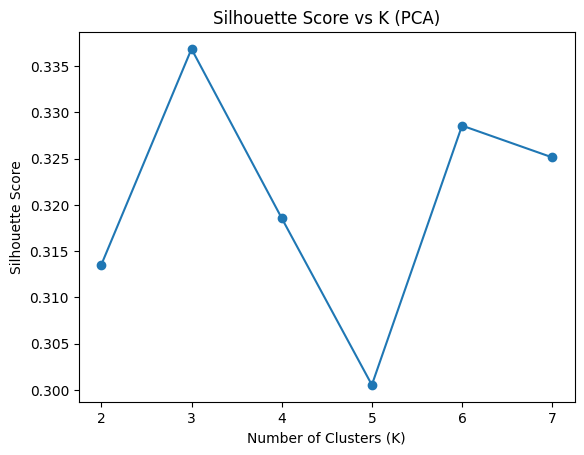

Best K based on Silhouette Score: 3


/tmp/ipython-input-75695944.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["cluster"] = kmeans.fit_predict(X_pca)


Final Silhouette Score: 0.3369185445629619


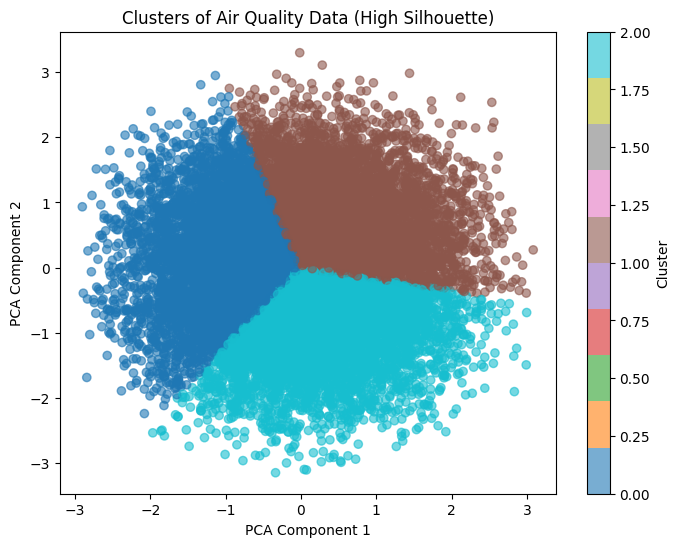

In [ ]:
# =====================================
# 1. Import Required Libraries
# =====================================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy import stats
import numpy as np

# =====================================
# 2. Load Dataset
# =====================================
df = pd.read_csv("globalAirQuality.csv")
print("Dataset Shape:", df.shape)

# =====================================
# 3. Feature Selection (Highly Important)
# =====================================
features = ["pm25", "pm10", "no2", "so2"]
X = df[features]

# =====================================
# 4. Handle Missing Values
# =====================================
df[features] = X.fillna(X.median())

# =====================================
# 5. Aggressively Remove Outliers
# =====================================
z = np.abs(stats.zscore(df[features]))
df_clean = df[(z < 2).all(axis=1)]  # stricter Z-score threshold
X_clean = df_clean[features]
print("Shape after outlier removal:", df_clean.shape)

# =====================================
# 6. Feature Scaling
# =====================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# =====================================
# 7. Dimensionality Reduction with PCA
# =====================================
# Keep 2 components for better separation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# =====================================
# 8. Find Optimal K using Silhouette Score
# =====================================
sil_scores = []
K_range = range(2, 8)  # smaller K usually gives higher silhouette
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    sil_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.3f}")

plt.figure()
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K (PCA)")
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print(f"Best K based on Silhouette Score: {best_k}")

# =====================================
# 9. Train Final K-Means Model
# =====================================
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=40)
df_clean["cluster"] = kmeans.fit_predict(X_pca)

# =====================================
# 10. Final Silhouette Score
# =====================================
sil_score = silhouette_score(X_pca, df_clean["cluster"])
print("Final Silhouette Score:", sil_score)

# =====================================
# 11. Visualize Clusters
# =====================================
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_clean["cluster"],
    cmap="tab10",
    alpha=0.6
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Clusters of Air Quality Data (High Silhouette)")
plt.colorbar(label="Cluster")
plt.show()



Test Data with Predicted Clusters:
   pm25  pm10  no2  so2  cluster
0    12    20   15    5        1
1    25    40   20    8        1
2    18    35   22   10        1
3    80   120   60   15        1
4     1     2    1    2        1
5     5    10    5    1        1
6    55    90   45   20        1
7    30    60   35   12        1
8     3     8    2    1        1
9   100   150   70   25        1


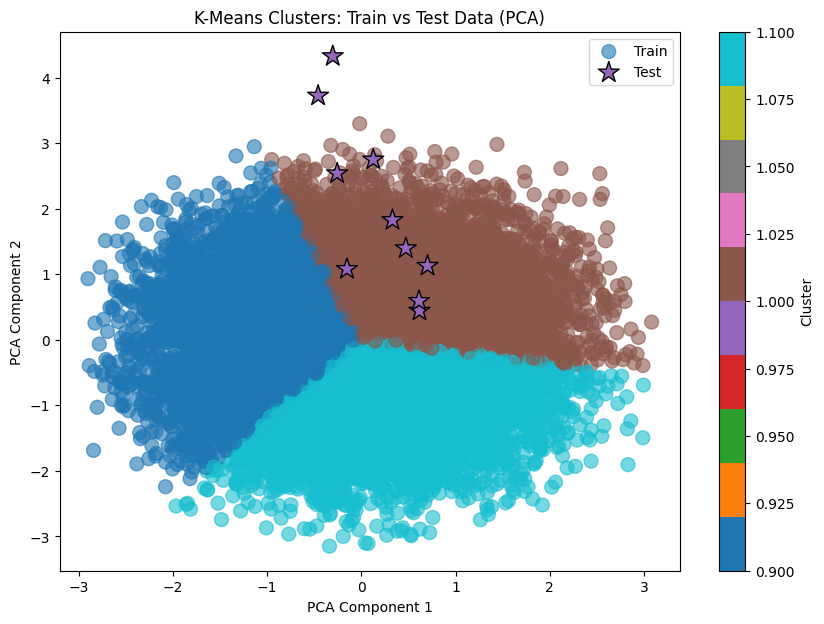

In [ ]:
import pandas as pd
import numpy as np

# =====================================
# 1. Test Data (Important Features Only)
# =====================================
X_test = pd.DataFrame([
    {"pm25": 12, "pm10": 20, "no2": 15, "so2": 5},      # Moderate pollution
    {"pm25": 25, "pm10": 40, "no2": 20, "so2": 8},      # Slightly higher
    {"pm25": 18, "pm10": 35, "no2": 22, "so2": 10},     # Moderate-high
    {"pm25": 80, "pm10": 120, "no2": 60, "so2": 15},    # Extreme pollution
    {"pm25": 1, "pm10": 2, "no2": 1, "so2": 2},        # Very low pollution
    {"pm25": 5, "pm10": 10, "no2": 5, "so2": 1},       # Low pollution
    {"pm25": 55, "pm10": 90, "no2": 45, "so2": 20},    # High pollution
    {"pm25": 30, "pm10": 60, "no2": 35, "so2": 12},    # High-moderate
    {"pm25": 3, "pm10": 8, "no2": 2, "so2": 1},        # Very low
    {"pm25": 100, "pm10": 150, "no2": 70, "so2": 25},  # Extremely high
])

# =====================================
# 2. Scale Test Data (Same scaler as training)
# =====================================
X_test_scaled = scaler.transform(X_test)

# =====================================
# 3. Apply PCA (Same PCA as training)
# =====================================
X_test_pca = pca.transform(X_test_scaled)

# =====================================
# 4. Predict Clusters
# =====================================
X_test["cluster"] = kmeans.predict(X_test_pca)

print("\nTest Data with Predicted Clusters:")
print(X_test)

# =====================================
# 5. Optional: Visualize with Training Clusters
# =====================================
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
# Training data
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_clean["cluster"], cmap='tab10', s=100, alpha=0.6, label='Train')
# Test data
plt.scatter(X_test_pca[:,0], X_test_pca[:,1], c=X_test["cluster"], cmap='tab10', s=250, marker='*', edgecolor='k', label='Test')

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters: Train vs Test Data (PCA)")
plt.legend()
plt.colorbar(label="Cluster")
plt.show()


Shape after outlier removal: (14944, 15)
Clusters: 2 | Silhouette Score: 0.130 | Davies-Bouldin Index: 2.384
Clusters: 3 | Silhouette Score: 0.102 | Davies-Bouldin Index: 2.102
Clusters: 4 | Silhouette Score: 0.089 | Davies-Bouldin Index: 1.818
Clusters: 5 | Silhouette Score: 0.093 | Davies-Bouldin Index: 1.849
Clusters: 6 | Silhouette Score: 0.080 | Davies-Bouldin Index: 1.676
Clusters: 7 | Silhouette Score: 0.082 | Davies-Bouldin Index: 1.787

Best number of clusters based on silhouette score: 2


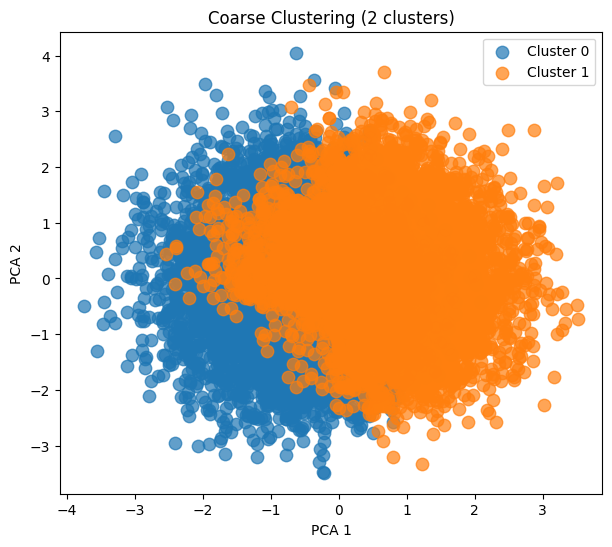

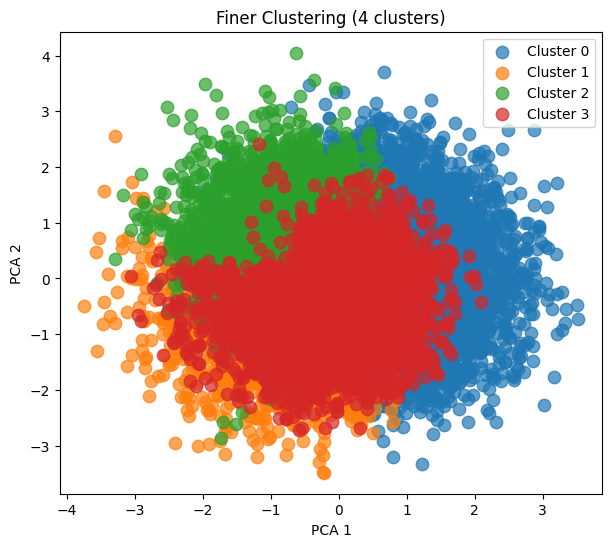

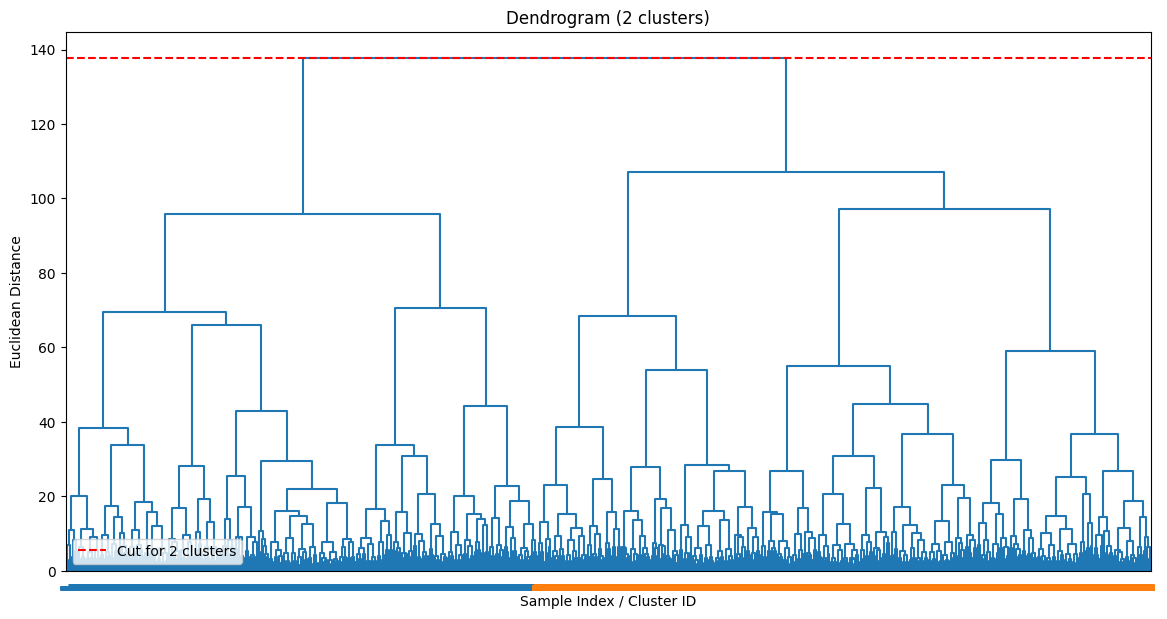

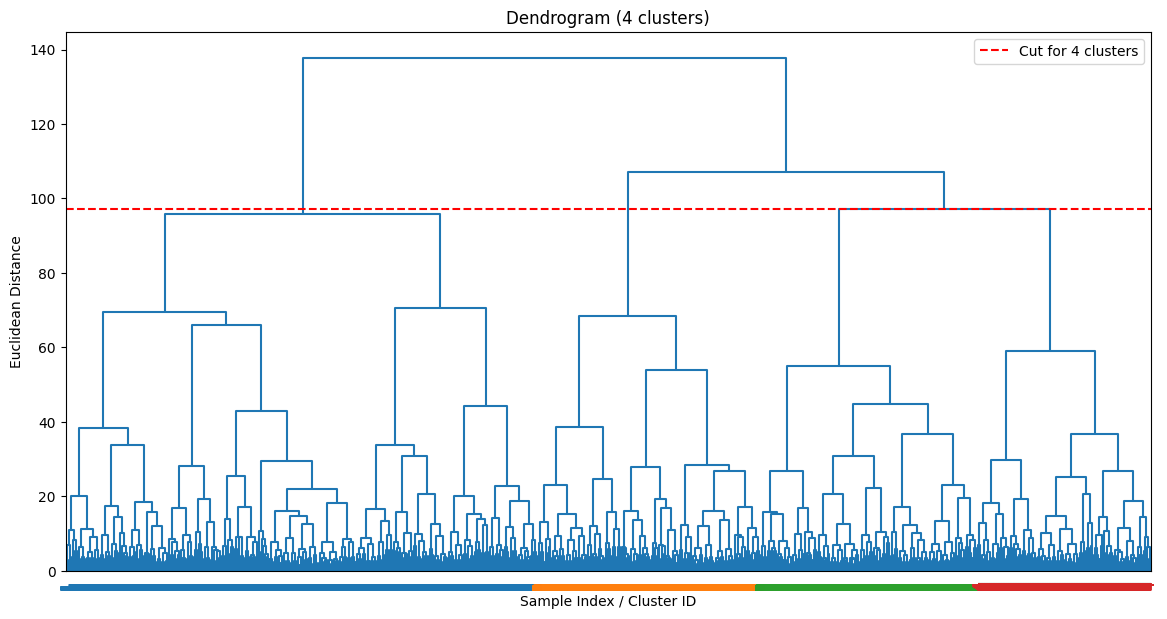


Coarse cluster distribution:
 0    10170
1     7830
Name: count, dtype: int64

Finer cluster distribution:
 0    7830
2    3698
3    3607
1    2865
Name: count, dtype: int64


In [ ]:
# ==============================
# Agglomerative Clustering Algorithm
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# ==============================
# 1. Load Data
# ==============================
df = pd.read_csv("globalAirQuality.csv")
features = ["pm25", "pm10", "no2", "so2"]
X = df[features]


# ==============================
# 2. Scale Data
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =====================================
#  Handle Missing Values
# =====================================
df[features] = X.fillna(X.median())

# =====================================
#  Aggressively Remove Outliers
# =====================================
z = np.abs(stats.zscore(df[features]))
df_clean = df[(z < 2).all(axis=1)]  # stricter Z-score threshold
X_clean = df_clean[features]
print("Shape after outlier removal:", df_clean.shape)

# ==============================
# 3. Find Optimal Number of Clusters
# ==============================
range_n_clusters = list(range(2, 8))
sil_scores = []
db_scores = []

for n_clusters in range_n_clusters:
    clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    labels = clustering.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)

    sil_scores.append(sil)
    db_scores.append(db)
    print(f"Clusters: {n_clusters} | Silhouette Score: {sil:.3f} | Davies-Bouldin Index: {db:.3f}")

best_n = range_n_clusters[np.argmax(sil_scores)]
print(f"\nBest number of clusters based on silhouette score: {best_n}")

# Optional finer cluster (visual choice)
finer_n = 4

# ==============================
# 4. Train Models
# ==============================
hier_best = AgglomerativeClustering(n_clusters=best_n, linkage='ward')
labels_best = hier_best.fit_predict(X_scaled)
df['cluster_best'] = labels_best

hier_finer = AgglomerativeClustering(n_clusters=finer_n, linkage='ward')
labels_finer = hier_finer.fit_predict(X_scaled)
df['cluster_finer'] = labels_finer

# ==============================
# 5. PCA for Visualization
# ==============================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

def plot_pca_clusters(X_pca, cluster_labels, n_clusters, title):
    palette = np.array(sns.color_palette("tab10", n_colors=n_clusters))
    plt.figure(figsize=(7,6))
    for cluster_id in range(n_clusters):
        plt.scatter(
            X_pca[cluster_labels == cluster_id, 0],
            X_pca[cluster_labels == cluster_id, 1],
            s=80,
            alpha=0.7,
            label=f'Cluster {cluster_id}',
            color=palette[cluster_id]
        )
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(title)
    plt.legend()
    plt.show()

# Coarse clustering PCA
plot_pca_clusters(X_pca, labels_best, best_n, f"Coarse Clustering ({best_n} clusters)")

# Finer clustering PCA
plot_pca_clusters(X_pca, labels_finer, finer_n, f"Finer Clustering ({finer_n} clusters)")

# ==============================
# 6. Dendrograms with Cut Line and Colored Leaves
# ==============================
def plot_dendrogram_with_cut(X_scaled, n_clusters, title):
    linked = linkage(X_scaled, method='ward')
    cluster_labels = fcluster(linked, t=n_clusters, criterion='maxclust')

    palette = np.array(sns.color_palette("tab10", n_colors=n_clusters))

    plt.figure(figsize=(14,7))
    dendro = dendrogram(
        linked,
        labels=cluster_labels,
        leaf_rotation=90,
        leaf_font_size=10,
        color_threshold=0
    )

    # Color leaves according to cluster
    ax = plt.gca()
    xlbls = ax.get_xmajorticklabels()
    for lbl in xlbls:
        cluster_id = int(lbl.get_text())
        lbl.set_color(palette[cluster_id - 1])

    # Draw horizontal line to show the cut for clusters
    cut_height = max(linked[-(n_clusters-1), 2], 0)
    plt.axhline(y=cut_height, color='red', linestyle='--', label=f'Cut for {n_clusters} clusters')

    plt.title(title)
    plt.xlabel("Sample Index / Cluster ID")
    plt.ylabel("Euclidean Distance")
    plt.legend()
    plt.show()

# Dendrograms
plot_dendrogram_with_cut(X_scaled, best_n, f"Dendrogram ({best_n} clusters)")
plot_dendrogram_with_cut(X_scaled, finer_n, f"Dendrogram ({finer_n} clusters)")

# ==============================
# 7. Cluster Distributions
# ==============================
print("\nCoarse cluster distribution:\n", pd.Series(labels_best).value_counts())
print("\nFiner cluster distribution:\n", pd.Series(labels_finer).value_counts())

Shape after outlier removal: (14944, 15)
Cluster counts:
optics_cluster
0    18000
Name: count, dtype: int64


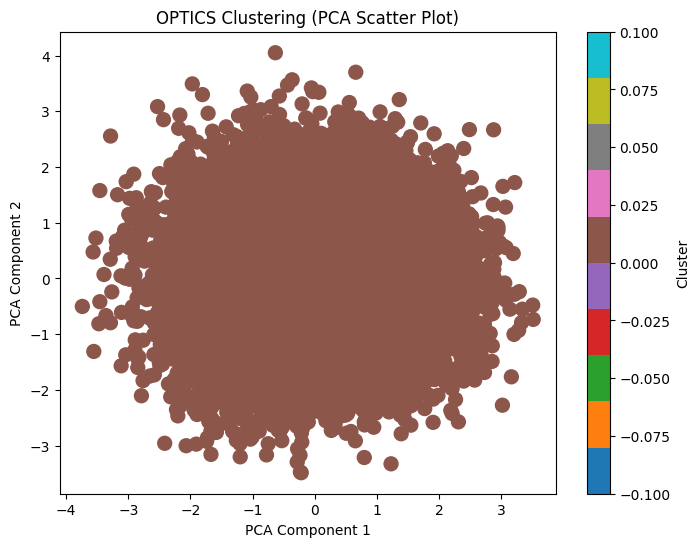

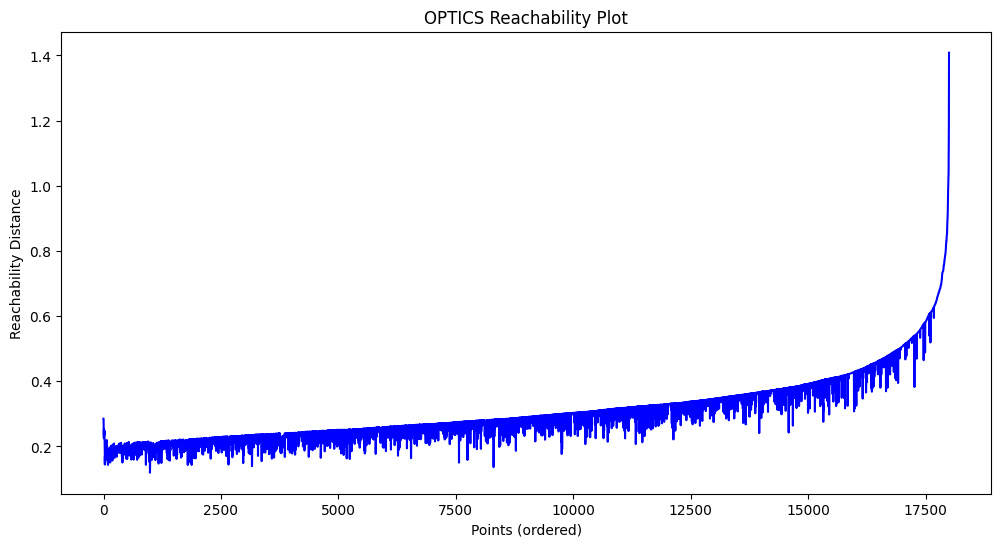

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import OPTICS
from scipy import stats
import numpy as np

# ==============================
# 1. Load Data
# ==============================
df = pd.read_csv("globalAirQuality.csv")

features = ["pm25", "pm10", "no2", "so2"]


X = df[features]

# ==============================
# 2. Scale Data
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =====================================
#  Handle Missing Values
# =====================================
df[features] = X.fillna(X.median())

# =====================================
#  Aggressively Remove Outliers
# =====================================
z = np.abs(stats.zscore(df[features]))
df_clean = df[(z < 2).all(axis=1)]  # stricter Z-score threshold
X_clean = df_clean[features]
print("Shape after outlier removal:", df_clean.shape)

# ==============================
# 3. Apply OPTICS
# ==============================
optics_model = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05)
df['optics_cluster'] = optics_model.fit_predict(X_scaled)

print("Cluster counts:")
print(df['optics_cluster'].value_counts())

# ==============================
# 4. PCA for Visualization
# ==============================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['optics_cluster'], cmap='tab10', s=100)
plt.title("OPTICS Clustering (PCA Scatter Plot)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label='Cluster')
plt.show()

# ==============================
# 5. Reachability Plot
# ==============================
plt.figure(figsize=(12,6))
reachability = optics_model.reachability_[optics_model.ordering_]
plt.plot(range(len(reachability)), reachability, color='b')
plt.title("OPTICS Reachability Plot")
plt.xlabel("Points (ordered)")
plt.ylabel("Reachability Distance")
plt.show()

Test Data:
   pm25  pm10  no2  so2
0    25    40   20    8
1   300   500  200  100
2    -5   -10   -2   -1
3    50    70   30   10

Test Data with Assigned Clusters:
   pm25  pm10  no2  so2  optics_cluster
0    25    40   20    8               0
1   300   500  200  100               0
2    -5   -10   -2   -1               0
3    50    70   30   10               0


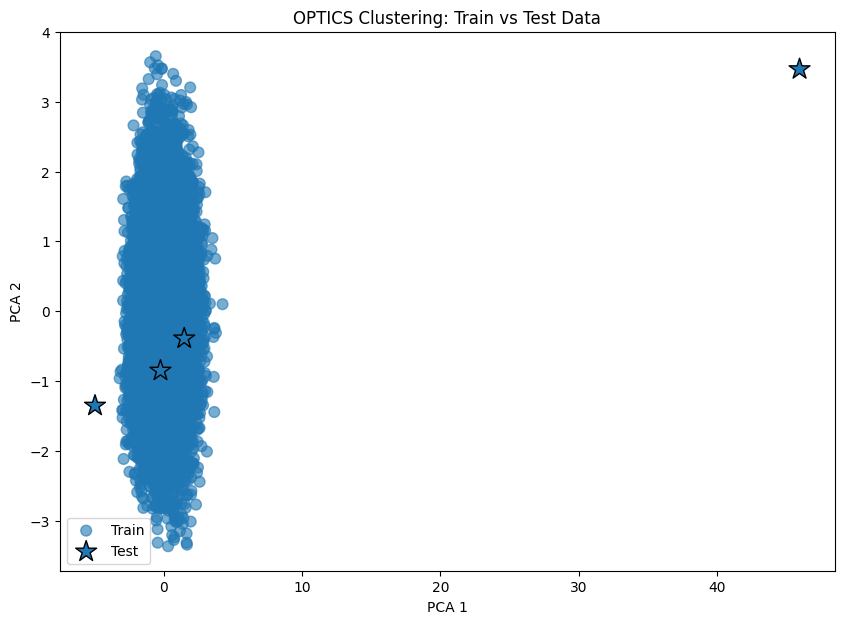

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import OPTICS
import matplotlib.pyplot as plt

# ==============================
# 1. Load train data and fit OPTICS
# ==============================
df_train = pd.read_csv("globalAirQuality.csv")

features = ["pm25", "pm10", "no2", "so2"]
X_train = df_train[features]

# Scale train data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Fit OPTICS
optics_model = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05)
df_train['optics_cluster'] = optics_model.fit_predict(X_train_scaled)

# ==============================
# 2. Prepare test data
# ==============================
X_test = pd.DataFrame([
    {"pm25": 25,  "pm10": 40,  "no2": 20,  "so2": 8},     # normal
    {"pm25": 300, "pm10": 500, "no2": 200, "so2": 100},  # extreme high
    {"pm25": -5,  "pm10": -10, "no2": -2,  "so2": -1},   # sensor error
    {"pm25": 50,  "pm10": 70,  "no2": 30,  "so2": 10},   # moderate
])

print("Test Data:")
print(X_test)

# Scale test data USING SAME SCALER
X_test_scaled = scaler.transform(X_test)

# ==============================
# 3. Assign test points to nearest cluster
# ==============================
# Remove noise points (-1)
mask = optics_model.labels_ != -1
core_samples = X_train_scaled[mask]
core_labels = optics_model.labels_[mask]

# Nearest Neighbor mapping
nn = NearestNeighbors(n_neighbors=1)
nn.fit(core_samples)

distances, indices = nn.kneighbors(X_test_scaled)
test_clusters = core_labels[indices.flatten()]

X_test['optics_cluster'] = test_clusters

print("\nTest Data with Assigned Clusters:")
print(X_test)

# ==============================
# 4. PCA for visualization
# ==============================
pca = PCA(n_components=2)

combined_scaled = np.vstack([X_train_scaled, X_test_scaled])
combined_pca = pca.fit_transform(combined_scaled)

# Split back
train_pca = combined_pca[:len(X_train)]
test_pca = combined_pca[len(X_train):]

df_train['PCA1'] = train_pca[:, 0]
df_train['PCA2'] = train_pca[:, 1]

X_test['PCA1'] = test_pca[:, 0]
X_test['PCA2'] = test_pca[:, 1]

# ==============================
# 5. Plot
# ==============================
plt.figure(figsize=(10, 7))

plt.scatter(
    df_train['PCA1'],
    df_train['PCA2'],
    c=df_train['optics_cluster'],
    cmap='tab10',
    s=60,
    alpha=0.6,
    label='Train'
)

plt.scatter(
    X_test['PCA1'],
    X_test['PCA2'],
    c=X_test['optics_cluster'],
    cmap='tab10',
    s=250,
    marker='*',
    edgecolor='black',
    label='Test'
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('OPTICS Clustering: Train vs Test Data')
plt.legend()
plt.show()